# LodeSTAR applied to dataset BF-C2DL-HSC

<!--<badge>--><a href="https://colab.research.google.com/github/softmatterlab/DeepTrack-2.0/blob/develop/examples/LodeSTAR/03.track_BF-C2DL-HSC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><!--</badge>-->

In [ ]:
%matplotlib inline
# !pip install deeptrack deeplay # Uncomment if running on Colab/Kaggle

In [ ]:
import os

import deeptrack as dt
import deeplay as dl
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
from torchvision.datasets.utils import _extract_zip, download_url

### 1. Define helper functions

In [ ]:
dataset_path = "cell_detection_dataset"
if not os.path.exists(dataset_path):
    url = ("http://data.celltrackingchallenge.net/training-datasets/"
           "BF-C2DL-HSC.zip")
    download_url(url, ".")
    _extract_zip("BF-C2DL-HSC.zip", dataset_path, None)
    os.remove("BF-C2DL-HSC.zip")
dir = os.path.join(dataset_path, "BF-C2DL-HSC/02")

def load_tif_movie(tif_dir):
    """Loads Data."""

    tif_files = sorted([
        os.path.join(tif_dir, f) for f in os.listdir(tif_dir) if f.lower().endswith(".tif")
    ])
    frames = [np.array(Image.open(f)) for f in tif_files]
    movie = np.stack(frames, axis=0)
    return movie

def normalize_min_max(img, squeeze_in_2D=False):
    """Normalizes intensities."""
    if squeeze_in_2D:
        img = np.squeeze(img)
    max_intensity = np.max(img)
    min_intensity = np.min(img)
    if max_intensity == min_intensity:
        raise ValueError("Cannot normalize array with uniform intensity.")
    normalized_img = (img - min_intensity) / (
        max_intensity - min_intensity)
    return normalized_img

### 2. Load data

In [ ]:
movie = load_tif_movie(dir)

# Reduce the large dataset to a subset.
movie = movie[:363]

# Normalize.
movie = normalize_min_max(movie)
print(f"Loaded {movie.shape[0]} frames of size {movie.shape[1]}x{movie.shape[2]}")

Loaded 363 frames of size 1010x1010


### 3. Obtain Crop

(40, 40)


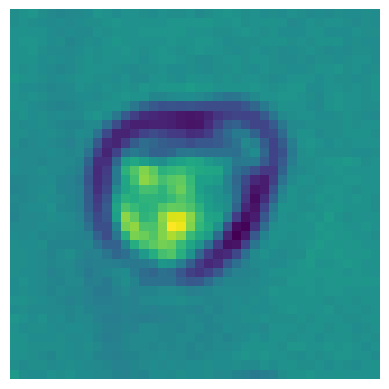

In [24]:
t, x, y, w = (251, 80, 538, 40)
crop = movie[t, y:y+w, x:x+w]
plt.imshow(crop)
plt.axis("off")
print(crop.shape)

### 4. Train Model

INFO: 
  | Name          | Type                       | Params | Mode 
---------------------------------------------------------------------
0 | model         | ConvolutionalNeuralNetwork | 251 K  | train
1 | between_loss  | L1Loss                     | 0      | train
2 | within_loss   | L1Loss                     | 0      | train
3 | train_metrics | MetricCollection           | 0      | train
4 | val_metrics   | MetricCollection           | 0      | train
5 | test_metrics  | MetricCollection           | 0      | train
6 | optimizer     | Adam                       | 0      | train
---------------------------------------------------------------------
251 K     Trainable params
0         Non-trainable params
251 K     Total params
1.004     Total estimated model params size (MB)
39        Modules in train mode
0         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                       | Params | Mode 
------------------------------------

Training: |          | 0/? [00:00<?, ?it/s]

(<Figure size 1500x500 with 2 Axes>,
 array([<Axes: title={'center': 'Between image disagreement'}, xlabel='Step'>,
        <Axes: title={'center': 'Within image disagreement'}, xlabel='Step'>],
       dtype=object))

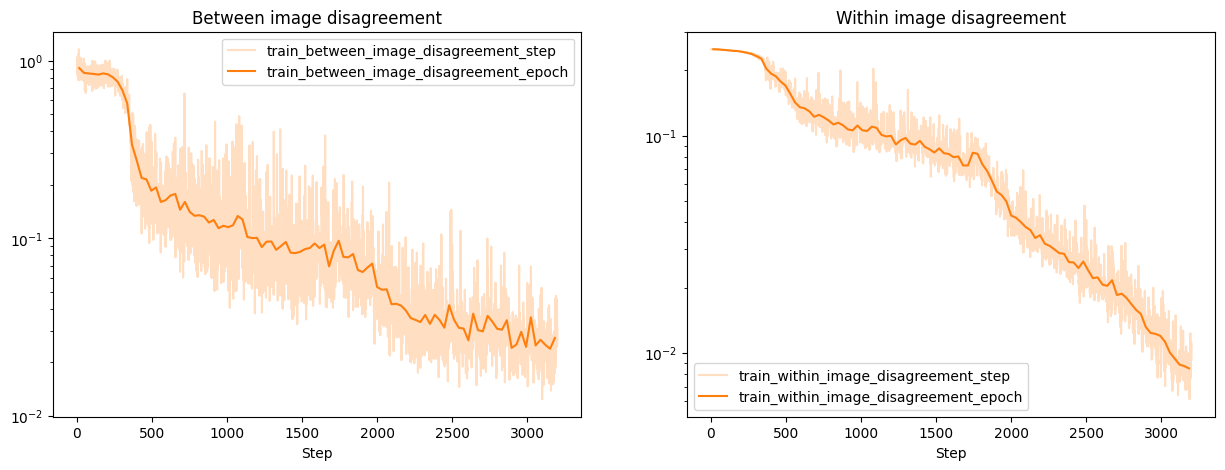

In [ ]:
# Add empty batch dimension for compatability.
training_crop = crop[np.newaxis]

# Instance LodeSTAR.
model = dl.LodeSTAR(n_transforms=4, optimizer=dl.Adam(lr=1e-4)).build()

# Define training pipeline, dataset, dataloader.
training_pipeline =   (
    dt.Value(training_crop)
    >> dt.Add(lambda: np.random.randn() * 0.1)
    >> dt.Gaussian(sigma=lambda:np.random.uniform(0, 0.2))  
    >> dt.Multiply(lambda: np.random.uniform(0.6, 1.2))
    >> dt.NormalizeMinMax()
    >> dt.pytorch.ToTensor(dtype=torch.float32)
)
train_dataset = dt.pytorch.Dataset(
     training_pipeline,
     length=256,
     replace=False,
)
dataloader = dl.DataLoader(
     train_dataset,
     batch_size=8,
     shuffle=True,
)

# Start training.
trainer_lodestar = dl.Trainer(max_epochs=100, accelerator="cuda")
trainer_lodestar.fit(model, dataloader)

# Plot history and save weights.
trainer_lodestar.history.plot()
torch.save(model.state_dict(), "lodestar_weights_BF-C2DL-HSC.pth")

### 5. Test Model

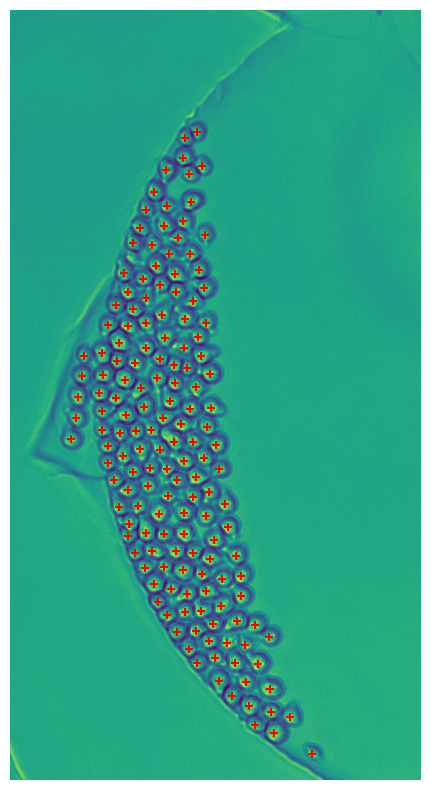

In [ ]:
# May need to tune these to get optimal performance!
alpha = 0.2
cutoff = 0.986

# Last frame of the movie.
frame_index = -1
image = normalize_min_max(movie[frame_index])

# Crop to focus on the cells.
image = image[130:-130, :400]

# Convert to tensor for LodeSTAR.
image = torch.as_tensor(
    image,
    dtype=torch.float32
).detach().unsqueeze(0).unsqueeze(0).to("cuda")
detections = model.detect(image, alpha=alpha, beta=1-alpha, cutoff=cutoff, mode="quantile")[0]

plt.figure(figsize=(10, 10))
plt.imshow(image.cpu()[0, 0, :, :])
plt.axis("off")
plt.scatter(detections[:, 1], detections[:, 0], color="r", marker="+")